# Test

In [1]:
# import pandas as pd
# import glob
# import os
# import matplotlib.pyplot as plt

# # =========================
# # CONFIG
# # =========================
# ROOT_DIR = r"C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-MNIST\prune_layers_ALL\p-percentage_0.0\batch_size_64"
# FILE_PATTERN = "slp_0.0_64_run_*"
# OUTPUT_CSV = "averaged_runs.csv"
# MIN_RUNS_PER_BATCH = 5  # ignore tail batches with very few runs


# df = pd.read_csv(files[0], sep=r"\s+")
# print(df.columns.tolist())
# df.columns = df.columns.str.strip()

# df = df.rename(columns={
#     "Accuracy(%)": "Accuracy"
# })


# # =========================
# # LOAD ALL RUNS
# # =========================
# files = glob.glob(os.path.join(ROOT_DIR, FILE_PATTERN))

# if len(files) == 0:
#     raise FileNotFoundError("No run files found. Check path or filename pattern.")

# dfs = []

# for f in files:
#     # print(f"Loading {os.path.basename(f)}")

#     # ---- If CSV ----
#     df = pd.read_csv(f)

#     # ---- If whitespace-separated, use this instead ----
#     # df = pd.read_csv(f, sep=r"\s+")

#     dfs.append(df)

# all_runs = pd.concat(dfs, ignore_index=True)

# print(f"\nLoaded {len(files)} runs")
# print(f"Total rows: {len(all_runs)}")

# # =========================
# # GROUP + AVERAGE
# # =========================
# avg_df = (
#     all_runs
#     .groupby("Batch_Number", as_index=False)
#     .agg(
#         Avg_CE_Train=("CE_Train", "mean"),
#         Std_CE_Train=("CE_Train", "std"),
#         Avg_Accuracy=("Accuracy(%)", "mean"),
#         Std_Accuracy=("Accuracy(%)", "std"),
#         Avg_CE_Test=("CE_TEST", "mean"),
#         Std_CE_Test=("CE_TEST", "std"),
#         Num_Runs=("CE_TEST", "count"),
#     )
# )

# # =========================
# # FILTER TAIL NOISE
# # =========================
# avg_df = avg_df[avg_df["Num_Runs"] >= MIN_RUNS_PER_BATCH]

# # =========================
# # SAVE OUTPUT
# # =========================
# output_path = os.path.join(ROOT_DIR, OUTPUT_CSV)
# avg_df.to_csv(output_path, index=False)

# print(f"\nSaved averaged data to: {output_path}")

# # =========================
# # PLOTS
# # =========================

# # ---- Avg CE Train ----
# plt.figure()
# plt.plot(avg_df["Batch_Number"], avg_df["Avg_CE_Train"])
# plt.fill_between(
#     avg_df["Batch_Number"],
#     avg_df["Avg_CE_Train"] - avg_df["Std_CE_Train"],
#     avg_df["Avg_CE_Train"] + avg_df["Std_CE_Train"],
#     alpha=0.2
# )
# plt.xlabel("Batch Number")
# plt.ylabel("Avg CE Train")
# plt.title("Average Training Loss Across Runs")
# plt.grid(True)
# plt.show()

# # ---- Avg Accuracy ----
# plt.figure()
# plt.plot(avg_df["Batch_Number"], avg_df["Avg_Accuracy"])
# plt.fill_between(
#     avg_df["Batch_Number"],
#     avg_df["Avg_Accuracy"] - avg_df["Std_Accuracy"],
#     avg_df["Avg_Accuracy"] + avg_df["Std_Accuracy"],
#     alpha=0.2
# )
# plt.xlabel("Batch Number")
# plt.ylabel("Avg Accuracy (%)")
# plt.title("Average Accuracy Across Runs")
# plt.grid(True)
# plt.show()

# # ---- Avg CE Test ----
# plt.figure()
# plt.plot(avg_df["Batch_Number"], avg_df["Avg_CE_Test"])
# plt.fill_between(
#     avg_df["Batch_Number"],
#     avg_df["Avg_CE_Test"] - avg_df["Std_CE_Test"],
#     avg_df["Avg_CE_Test"] + avg_df["Std_CE_Test"],
#     alpha=0.2
# )
# plt.xlabel("Batch Number")
# plt.ylabel("Avg CE Test")
# plt.title("Average Test Loss Across Runs")
# plt.grid(True)
# plt.show()


# Plotting

## Loading the data

In [1]:
%matplotlib inline

In [2]:

import pandas as pd
import glob
import os
import matplotlib.pyplot as plt

# =========================
# CONFIG
# =========================
ROOT_DIR = r"C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-MNIST\prune_layers_ALL\p-percentage_0.0\batch_size_64"
FILE_PATTERN = "slp_0.0_64_run_*"

# =========================
# LOAD ALL RUN FILES
# =========================
files = glob.glob(os.path.join(ROOT_DIR, FILE_PATTERN))

if not files:
    raise FileNotFoundError("No run files found.")

dfs = []

for f in files:
    # print(f"Loading {os.path.basename(f)}")

    # Your logs are whitespace-separated
    df = pd.read_csv(f, sep=r"\s+")

    # Clean column names
    df.columns = df.columns.str.strip()
    # Convert CE_Train to numeric, force '--' → NaN
    df["CE_Train"] = pd.to_numeric(df["CE_Train"], errors="coerce")


    dfs.append(df)

print(f"\nLoaded {len(dfs)} runs")

# =========================
# VERIFY COLUMNS (ONCE)
# =========================
print("\nDetected columns:")
print(dfs[0].columns.tolist())





Loaded 100 runs

Detected columns:
['Current_Epoch', 'Batch/Total', 'CE_Train', 'Accuracy(%)', 'CE_TEST', 'Batch_Number']


## Plotting all the averages

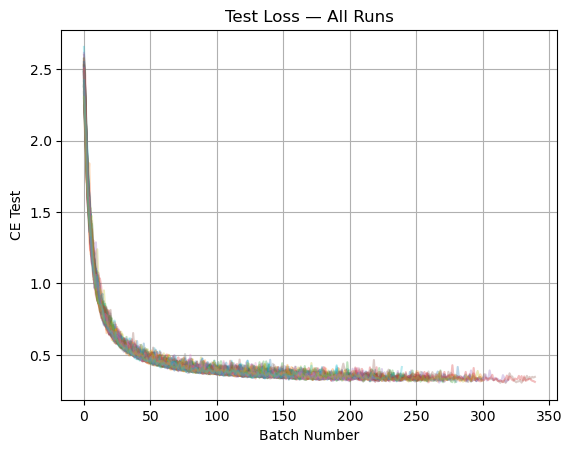

In [3]:


# =========================
# PLOT ALL RUNS — TEST LOSS
# =========================
plt.figure()
for df in dfs:
    plt.plot(df["Batch_Number"], df["CE_TEST"], alpha=0.3)

plt.xlabel("Batch Number")
plt.ylabel("CE Test")
plt.title("Test Loss — All Runs")
plt.grid(True)
plt.show(block = True)


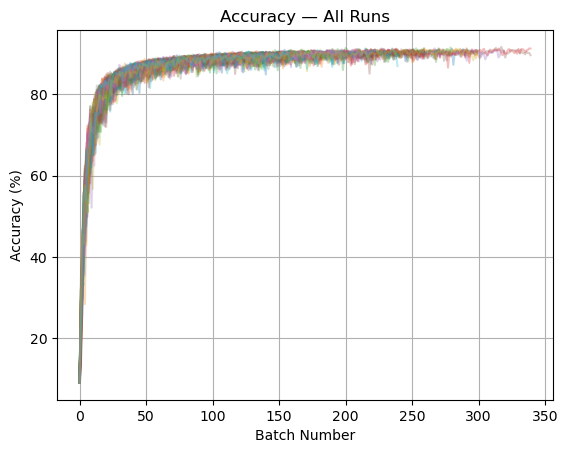

In [4]:
# =========================
# PLOT ALL RUNS — ACCURACY
# =========================
plt.figure()
for df in dfs:
    plt.plot(df["Batch_Number"], df["Accuracy(%)"], alpha=0.3)

plt.xlabel("Batch Number")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy — All Runs")
plt.grid(True)
plt.show()


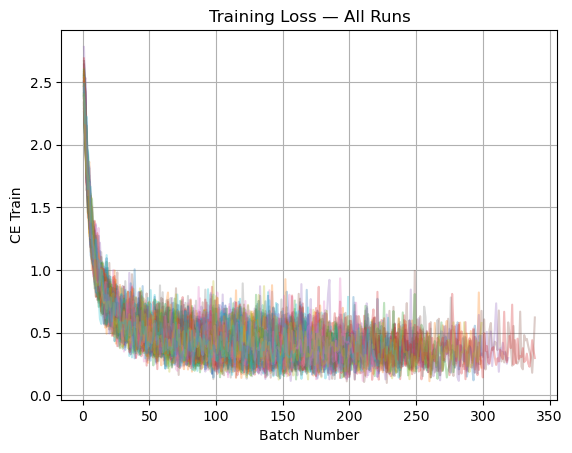

In [5]:
# =========================
# PLOT ALL RUNS — TRAIN LOSS
# =========================
plt.figure()
i = 0
for df in dfs:
    plt.plot(df["Batch_Number"], df["CE_Train"], alpha=0.3)


plt.xlabel("Batch Number")
plt.ylabel("CE Train")
plt.title("Training Loss — All Runs")
plt.grid(True)
plt.show()

## creating a single average run


Saved averaged data to:
C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-MNIST\prune_layers_ALL\p-percentage_0.0\batch_size_64\averaged_over_100_runs_full.csv


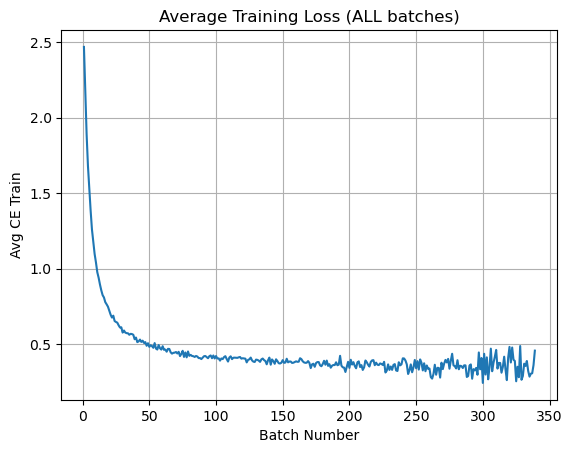

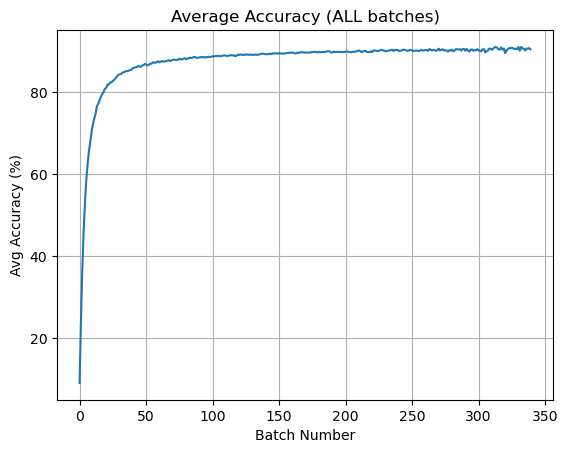

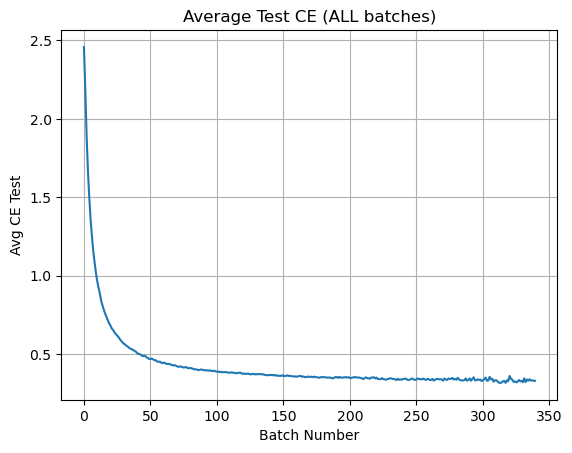

In [8]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt

# =========================
# CONFIG
# =========================
ROOT_DIR = r"C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-MNIST\prune_layers_ALL\p-percentage_0.0\batch_size_64"
FILE_PATTERN = "slp_0.0_64_run_*"
OUTPUT_CSV = "averaged_over_100_runs_full.csv"

# =========================
# LOAD ALL RUNS
# =========================
files = glob.glob(os.path.join(ROOT_DIR, FILE_PATTERN))
if not files:
    raise FileNotFoundError("No run files found.")

dfs = []

for f in files:
    # print(f"Loading", os.path.basename(f))

    df = pd.read_csv(f, sep=r"\s+")
    df.columns = df.columns.str.strip()

    # Convert strings to numbers
    df["CE_Train"] = pd.to_numeric(df["CE_Train"], errors="coerce")
    df["CE_TEST"] = pd.to_numeric(df["CE_TEST"], errors="coerce")
    df["Accuracy(%)"] = pd.to_numeric(df["Accuracy(%)"], errors="coerce")

    dfs.append(df)

all_runs = pd.concat(dfs, ignore_index=True)

# =========================
# GROUP + AVERAGE (NO FILTER)
# =========================
avg_df = (
    all_runs
    .groupby("Batch_Number", as_index=False)
    .agg(
        Avg_CE_Train=("CE_Train", "mean"),
        Avg_Accuracy=("Accuracy(%)", "mean"),
        Avg_CE_Test=("CE_TEST", "mean"),
        Num_Runs=("CE_TEST", "count")
    )
)

# =========================
# SAVE OUTPUT
# =========================
output_path = os.path.join(ROOT_DIR, OUTPUT_CSV)
avg_df.to_csv(output_path, index=False)

print(f"\nSaved averaged data to:\n{output_path}")

# =========================
# PLOTS
# =========================

plt.figure()
plt.plot(avg_df["Batch_Number"], avg_df["Avg_CE_Train"])
plt.xlabel("Batch Number")
plt.ylabel("Avg CE Train")
plt.title("Average Training Loss (ALL batches)")
plt.grid(True)
plt.show(block=True)

plt.figure()
plt.plot(avg_df["Batch_Number"], avg_df["Avg_Accuracy"])
plt.xlabel("Batch Number")
plt.ylabel("Avg Accuracy (%)")
plt.title("Average Accuracy (ALL batches)")
plt.grid(True)
plt.show(block=True)

plt.figure()
plt.plot(avg_df["Batch_Number"], avg_df["Avg_CE_Test"])
plt.xlabel("Batch Number")
plt.ylabel("Avg CE Test")
plt.title("Average Test CE (ALL batches)")
plt.grid(True)
plt.show(block=True)


## Curving fitting

0.33733057142857137


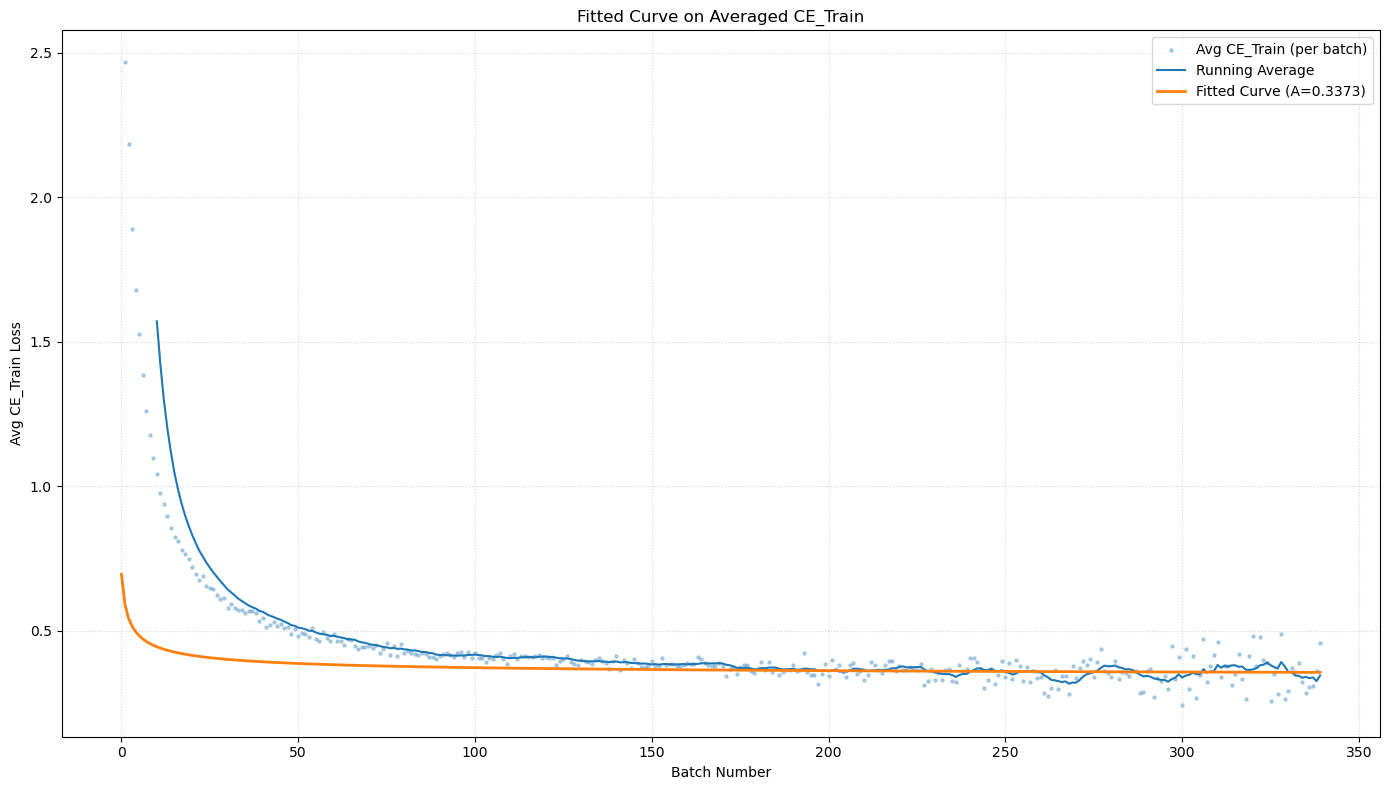

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lmfit import minimize, Parameters

# ================================
# CONFIGURATION
# ================================
DATA_FILE = r"C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-MNIST\prune_layers_ALL\p-percentage_0.0\batch_size_64\averaged_over_100_runs_full.csv"

RUNNING_AVG_WINDOW = 10

A_MIN, A_MAX = 0.1, 2.3
B_MIN, B_MAX = 0, 1000
N_MIN, N_MAX = 0.5, 3.0


# ================================
# HELPER FUNCTIONS
# ================================
def running_average(values, window=100):
    if len(values) < window:
        return np.nan
    return np.mean(values[-window:])

def initialize_guesses(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    y = y[np.isfinite(y)]

    A0 = np.percentile(y, 5)
    B0 = np.percentile(y, 95) - A0
    n0 = 0.5
    if len(x) > 10:
        frac = max(1e-6, (y[0] - y[-1]) / (y[0] - A0))
        if frac > 0:
            n0 = max(0.3, min(1.5, -np.log(frac)))
    return A0, n0, B0

def model(params, x):
    vals = params.valuesdict()
    A, B, n = vals['A'], vals['B'], vals['n']
    return A + B / ((x + 1)**n)

def residual(params, x, data):
    weight = x**2
    model_vals = model(params, x)
    return weight * (model_vals - data)

def fit_window(x, y):
    mask = ~np.isnan(y)
    x_fit = x[mask]
    y_fit = y[mask]
    if len(x_fit) < 10:
        return None, None

    A0, n0, B0 = initialize_guesses(x_fit, y_fit)
    params = Parameters()
    params.add('A', value=A0, min=A_MIN, max=A_MAX)
    params.add('B', value=B0, min=B_MIN, max=B_MAX)
    params.add('n', value=n0, min=N_MIN, max=N_MAX)

    try:
        out = minimize(residual, params, args=(x_fit, y_fit))
        return out, out.params['A'].value
    except:
        return None, None


# ================================
# LOAD AVERAGED DATA
# ================================
df = pd.read_csv(DATA_FILE)

batch_numbers = df["Batch_Number"].to_numpy()
ce_train_avg = df["Avg_CE_Train"].to_numpy()

# ================================
# RUNNING AVERAGE
# ================================
ravg = []
for i in range(len(ce_train_avg)):
    ravg.append(running_average(ce_train_avg[:i+1], window=RUNNING_AVG_WINDOW))
ravg = np.array(ravg)

# ================================
# FIT THE CURVE
# ================================
fit_result_at_stop, current_A = fit_window(batch_numbers, ravg)
print(current_A)

# ================================
# PLOT RESULTS
# ================================
plt.figure(figsize=(14,8))

plt.scatter(batch_numbers, ce_train_avg, alpha=0.3, s=5, label='Avg CE_Train (per batch)')
plt.plot(batch_numbers, ravg, linewidth=1.5, label='Running Average')

y_fit = model(fit_result_at_stop.params, batch_numbers)
plt.plot(batch_numbers, y_fit, linewidth=2,
         label=f'Fitted Curve (A={current_A:.4f})')

plt.xlabel('Batch Number')
plt.ylabel('Avg CE_Train Loss')
plt.title('Fitted Curve on Averaged CE_Train')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()
